<a href="https://colab.research.google.com/github/Rakib007Nabila/Detection-of-Parkinsons-Using-ML/blob/main/EE_MAC_07_09_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Round 100: 100 nodes alive, 
Round 200: 100 nodes alive, 
Round 300: 100 nodes alive, 
Round 400: 100 nodes alive, 
Round 500: 100 nodes alive, 
Round 600: 100 nodes alive, 
Round 700: 100 nodes alive, 
Round 800: 100 nodes alive, 
Round 900: 100 nodes alive, 
Round 1000: 100 nodes alive, 
Round 1100: 100 nodes alive, 
Round 1200: 100 nodes alive, 
Round 1300: 100 nodes alive, 
Round 1400: 100 nodes alive, 
Round 1500: 100 nodes alive, 
Round 1600: 100 nodes alive, 
Round 1700: 100 nodes alive, 
Round 1800: 100 nodes alive, 
Round 1900: 100 nodes alive, 
Round 2000: 100 nodes alive, 
Round 2100: 100 nodes alive, 
Round 2200: 100 nodes alive, 
Round 2300: 100 nodes alive, 
Round 2400: 100 nodes alive, 
Round 2500: 100 nodes alive, 
Round 2600: 100 nodes alive, 
Round 2700: 100 nodes alive, 
Round 2800: 100 nodes alive, 
Round 2900: 100 nodes alive, 
Round 3000: 100 nodes alive, 
Round 3100: 100 nodes alive, 
Round 3200: 100 nodes alive, 
Round 3300: 100 nodes alive, 
Round 3400: 100 nod

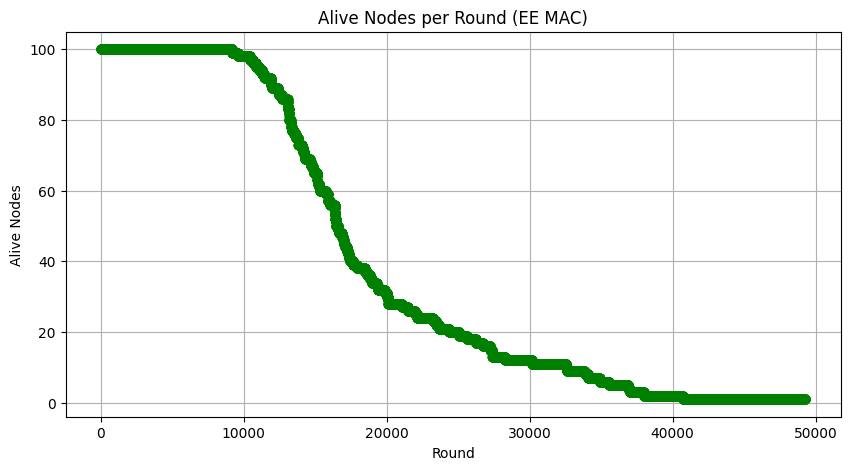

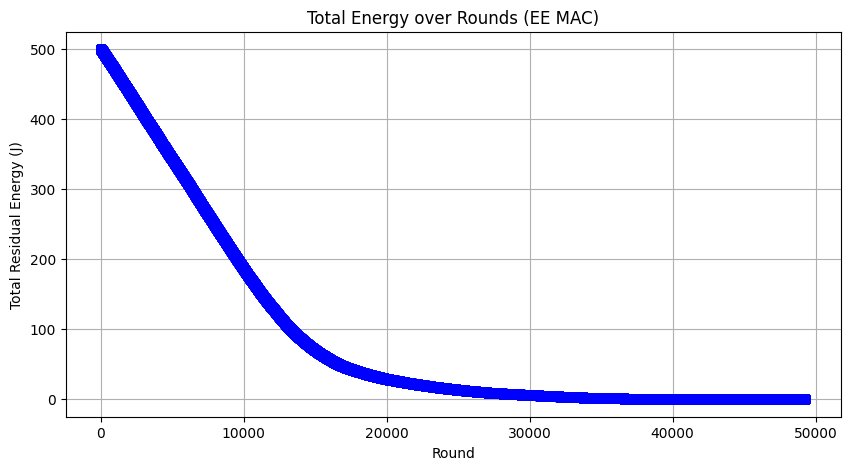

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ==============================
# Parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
P = 0.1            # desired CH probability
M_SESSIONS = 15     # number of TDMA frames (sessions) per round, set >1 to simulate more traffic
TE = 0.5            # Threshold energy for CH selection
PT = 30             # Proximity Threshold (radius for CH competition)
ICS = 10            # Idle Cluster Size
PR = 5              # Permissible Relaxation
MCS = ICS + PR      # Maximum Cluster Size

# Radio model parameters
E_ELEC = 50e-9       # J/bit
E_DA   = 5e-9        # J/bit
E_AMP  = 100e-12     # J/bit/m^2

# Packet sizes
K_DATA = 100 * 8     # 100 bytes = 800 bits
K_CTRL = 20 * 8      # 20 bytes = 160 bits

# ==============================
# Energy functions
# ==============================
def energy_tx(k_bits, distance):
    """ Energy consumed during transmission """
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    """ Energy consumed during reception """
    return E_ELEC * k_bits

def energy_da(k_bits):
    """ Energy consumed during data aggregation """
    return E_DA * k_bits

# ==============================
# Helper function
# ==============================
def calculate_distance(x1, y1, x2, y2):
    """ Calculate Euclidean distance between two points """
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# ==============================
# Node deployment
# ==============================
SEED = 42
np.random.seed(SEED)

# Random node deployment in the grid
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# Initial energy and other state variables
node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
death_round = {i: None for i in range(NUM_NODES)}
last_CH_round = {i: -int(1/P) for i in range(NUM_NODES)}  # track last CH round

alive_node_count_per_round = []
total_energy_per_round = []

# ==============================
# Simulation loop
# ==============================
round_num = 0
while any(e > 0 for e in node_energy.values()):
    round_num += 1
    alive_nodes = [i for i, e in node_energy.items() if e > 0]

    alive_node_count_per_round.append(len(alive_nodes))
    total_energy_per_round.append(sum(node_energy.values()))

    # --- Setup Phase ---
    selected_ch_ids = []
    G = [n for n in alive_nodes if node_energy[n] > TE and round_num - last_CH_round[n] >= int(1/P)]

    # CH selection based on energy and random number generation
    for node in G:
        T_n = P / (1 - P * ((round_num - 1) % int(1/P)))
        if np.random.rand() < T_n:
            selected_ch_ids.append(node)
            last_CH_round[node] = round_num

    if len(selected_ch_ids) == 0:
        # Ensure at least one CH is selected
        selected_ch_ids = [np.random.choice(alive_nodes)]
        last_CH_round[selected_ch_ids[0]] = round_num

    # --- Assign cluster members ---
    cluster_members = {ch: [] for ch in selected_ch_ids}
    for node_id in alive_nodes:
        if node_id in selected_ch_ids:
            continue
        # Assign to nearest CH based on proximity threshold (PT)
        dists = [calculate_distance(x_positions[node_id], y_positions[node_id],
                                    x_positions[ch], y_positions[ch]) for ch in selected_ch_ids]
        chosen_ch = selected_ch_ids[np.argmin(dists)]
        cluster_members[chosen_ch].append((node_id, min(dists)))

    # --- Energy consumption during setup phase (CSMA for ADV) ---
    for ch in selected_ch_ids:
        if node_energy[ch] <= 0:
            continue
        # CSMA for ADV packet broadcasting
        for node_id, _ in cluster_members[ch]:
            # Energy used to broadcast ADV packet
            dist_to_ch = calculate_distance(x_positions[node_id], y_positions[node_id], x_positions[ch], y_positions[ch])
            node_energy[node_id] -= energy_tx(K_CTRL, dist_to_ch)  # subtract energy

    # --- Steady-state Phase ---
    for ch, members in cluster_members.items():
        if node_energy[ch] <= 0:
            continue
        # Collect data from each member in TDMA slots
        for node_id, _ in members:
            if node_energy[node_id] > 0:
                dist_to_ch = calculate_distance(x_positions[node_id], y_positions[node_id], x_positions[ch], y_positions[ch])
                node_energy[node_id] -= energy_tx(K_DATA, dist_to_ch)  # subtract energy for transmission

        # Aggregating data and sending to BS
        dist_to_bs = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
        node_energy[ch] -= energy_tx(K_DATA, dist_to_bs)  # subtract energy for CH forwarding data to BS

    # --- Check for dead nodes ---
    for ch in selected_ch_ids:
        if node_energy[ch] <= 0 and death_round[ch] is None:
            death_round[ch] = round_num
    for node_id in alive_nodes:
        if node_energy[node_id] <= 0 and death_round[node_id] is None:
            death_round[node_id] = round_num

    # Print progress for debugging
    if round_num % 100 == 0:
        print(f"Round {round_num}: {len(alive_nodes)} nodes alive, ")

# ==============================
# Results
# ==============================
FND = min(death_round.values())
LND = max(death_round.values())

print("Simulation complete.")
print(f"First Node Death (FND): {FND}")
print(f"Last Node Death (LND): {LND}")

# --- Plot Alive Nodes ---
plt.figure(figsize=(10,5))
plt.plot(range(1, len(alive_node_count_per_round) + 1), alive_node_count_per_round, marker='o', color='green')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title(f"Alive Nodes per Round (EE MAC)")
plt.grid(True)
plt.show()

# --- Plot Total Energy ---
plt.figure(figsize=(10,5))
plt.plot(range(1, len(total_energy_per_round) + 1), total_energy_per_round, marker='s', color='blue')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title(f"Total Energy over Rounds (EE MAC)")
plt.grid(True)
plt.show()


EE-MAC: FND = 909 LND = 5129


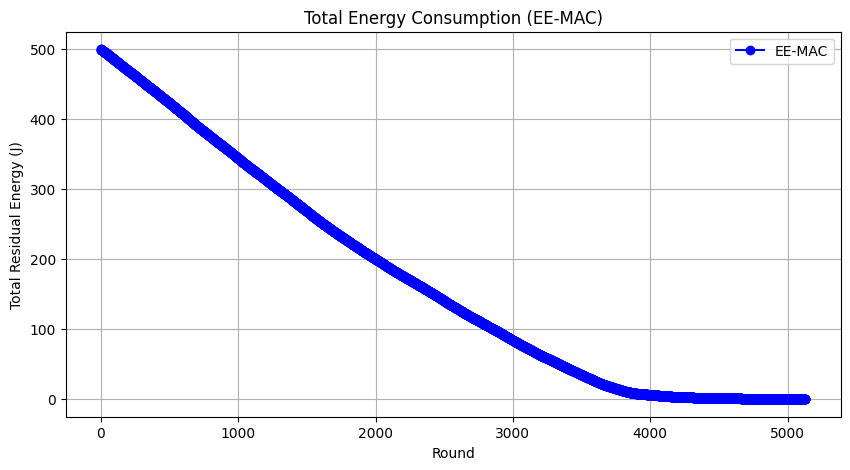

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ==============================
# Parameters
# ==============================
TE = 0.1  # Threshold Energy (J)
PT = 10   # Proximity Threshold (m)
MCS = 20  # Maximum Cluster Size (MCS)
VER = 0.05  # Verification Period (seconds)

# Update existing variables
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
P = 0.1  # Desired CH probability
M_SESSIONS = 15  # Number of TDMA frames per round

# Radio model parameters
E_ELEC = 50e-9  # Energy consumption for transmission per bit (J/bit)
E_DA   = 5e-9   # Energy for data aggregation per bit (J/bit)
E_AMP  = 100e-12  # Energy for amplification per bit per meter squared (J/bit/m^2)

# Packet sizes (in bits)
K_DATA = 100 * 8  # Data packet size (in bits)
K_CTRL = 20 * 8   # Control packet size (in bits)

# ==============================
# Node positions and Energy functions
# ==============================
SEED = 42
np.random.seed(SEED)
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# Energy functions
def energy_tx(k_bits, distance):
    """ Energy consumed during transmission """
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    """ Energy consumed during reception """
    return E_ELEC * k_bits

def energy_da(k_bits):
    """ Energy consumed during data aggregation """
    return E_DA * k_bits      #is that right

# Helper function to calculate distance
def calculate_distance(x1, y1, x2, y2):
    """ Calculate Euclidean distance between two points """
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# ==============================
# EE-MAC Simulation Function
# ==============================
def run_eemac():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}
    last_CH_round = {i: -int(1/P) for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0

    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH Selection (EE-MAC specific) ---
        selected_ch_ids = []
        G = [n for n in alive_nodes if round_num - last_CH_round[n] >= int(1/P)]
        for node in G:
            if node_energy[node] < TE:
                continue  # Skip nodes with low energy
            T_n = P / (1 - P * ((round_num - 1) % int(1/P)))
            if np.random.random() < T_n:
                selected_ch_ids.append(node)
                last_CH_round[node] = round_num

        # Prevent CHs from being too close to each other (Proximity Threshold)
        valid_ch_ids = []
        for node in G:
            if node_energy[node] < TE:
                continue
            too_close = False
            for ch in selected_ch_ids:
                if calculate_distance(x_positions[node], y_positions[node],
                                      x_positions[ch], y_positions[ch]) < PT:
                    too_close = True
                    break
            if not too_close:
                valid_ch_ids.append(node)
                last_CH_round[node] = round_num

        selected_ch_ids = valid_ch_ids

        # If no CHs selected, select a random one
        if len(selected_ch_ids) == 0:
            selected_ch_ids = [np.random.choice(alive_nodes)]
            last_CH_round[selected_ch_ids[0]] = round_num

        # --- Assign members ---
        cluster_members = {ch: [] for ch in selected_ch_ids}
        for node_id in alive_nodes:
            if node_id in selected_ch_ids:
                continue
            dists = [calculate_distance(x_positions[node_id], y_positions[node_id],
                                        x_positions[ch], y_positions[ch]) for ch in selected_ch_ids]
            chosen_ch = selected_ch_ids[np.argmin(dists)]
            if len(cluster_members[chosen_ch]) < MCS:
                cluster_members[chosen_ch].append((node_id, min(dists)))

        # --- Setup Phase Energy Consumption ---
        for node_id in alive_nodes:
            if node_id in selected_ch_ids:
                continue
            d_ch = min([calculate_distance(x_positions[node_id], y_positions[node_id],
                                           x_positions[ch], y_positions[ch]) for ch in selected_ch_ids])
            node_energy[node_id] -= (len(selected_ch_ids) * energy_rx(K_CTRL)  # Receive control messages
                                     + energy_tx(K_CTRL, d_ch)  # Transmit join request
                                     + energy_rx(K_CTRL))  # Receive response
            if node_energy[node_id] <= 0 and death_round[node_id] is None:
                death_round[node_id] = round_num

        for ch in selected_ch_ids:
            d_cluster = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
            n_members = len(cluster_members[ch])
            node_energy[ch] -= (energy_tx(K_CTRL, d_cluster)  # Send ADV
                                + n_members * energy_rx(K_CTRL)  # Receive JOIN requests
                                + energy_tx(K_CTRL, d_cluster))  # Broadcast TDMA schedule
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # --- Session Loop (Data Transmission) ---
        for session in range(M_SESSIONS):
            member_transmissions = {ch: [] for ch in selected_ch_ids}
            for ch, members in cluster_members.items():
                for node_id, d_ch in members:
                    if node_energy[node_id] <= 0:
                        continue
                    node_energy[node_id] -= energy_tx(K_DATA, d_ch)  # Data transmission
                    member_transmissions[ch].append(node_id)
                    if node_energy[node_id] <= 0 and death_round[node_id] is None:
                        death_round[node_id] = round_num

            for ch in selected_ch_ids:
                if node_energy[ch] <= 0:
                    continue
                num_recv = len(member_transmissions[ch])
                E_data_rx = num_recv * energy_rx(K_DATA)
                E_data_agg = num_recv * energy_da(K_DATA)
                d_bs = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
                E_tx_to_bs = energy_tx(K_DATA, d_bs)
                node_energy[ch] -= (E_data_rx + E_data_agg + E_tx_to_bs)  # Forward data to BS
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round

# ==============================
# Run the EE-MAC Simulation
# ==============================
alive_eemac, energy_eemac, death_eemac = run_eemac()

FND_eemac = min(death_eemac.values())
LND_eemac = max(death_eemac.values())

print("EE-MAC: FND =", FND_eemac, "LND =", LND_eemac)

# ==============================
# Plot Energy Consumption
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1, len(energy_eemac) + 1), energy_eemac, marker='o', color='blue', label='EE-MAC')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy Consumption (EE-MAC)")
plt.grid(True)
plt.legend()
plt.show()


EE-MAC: FND = 1251 LND = 3368


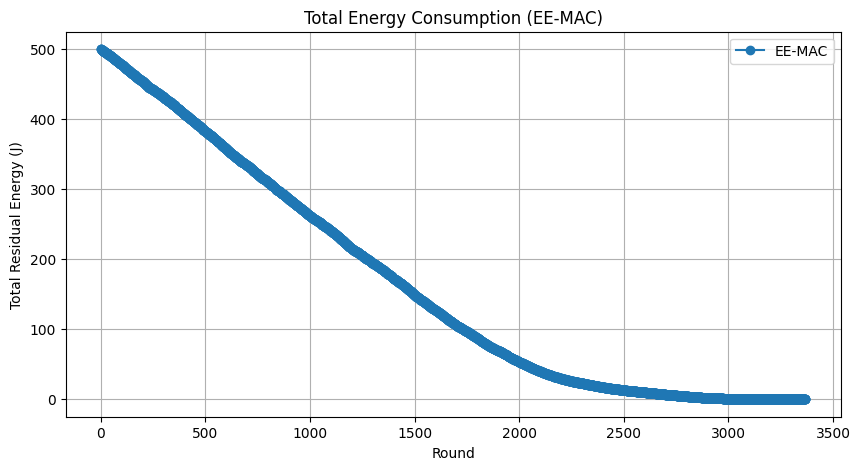

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ==============================
# Parameters
# ==============================
TE = 0.1  # Threshold Energy (J)
PT = 10   # Proximity Threshold (m)
MCS = 12  # Maximum Cluster Size (MCS)
VER = 0.05  # Verification Period (seconds)

# Update existing variables
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
P = 0.1  # Desired CH probability
M_SESSIONS = 15  # Number of TDMA frames per round

# Radio model parameters
E_ELEC = 50e-9  # Energy consumption for transmission per bit (J/bit)
E_DA   = 5e-9   # Energy for data aggregation per bit (J/bit)
E_AMP  = 100e-12  # Energy for amplification per bit per meter squared (J/bit/m^2)

# Packet sizes (in bits)
K_DATA = 100 * 8  # Data packet size (in bits)
K_CTRL = 20 * 8   # Control packet size (in bits)

# ==============================
# Node positions and Energy functions
# ==============================
SEED = 42
np.random.seed(SEED)
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# Energy functions
def energy_tx(k_bits, distance):
    """ Energy consumed during transmission """
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    """ Energy consumed during reception """
    return E_ELEC * k_bits

def energy_da(k_bits):
    """ Energy consumed during data aggregation """
    return E_DA * k_bits

# Helper function to calculate distance
def calculate_distance(x1, y1, x2, y2):
    """ Calculate Euclidean distance between two points """
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# ==============================
# EE-MAC Simulation Function (modified setup phase)
# ==============================
def run_eemac():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}
    # last round a node was CH; initialize so everyone is eligible at start
    last_CH_round = {i: -int(1/P) for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0

    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # ==============================
        # --- CH SELECTION (EE-MAC) ---
        # ==============================
        # G set: nodes that haven't been CH in last 1/P rounds (LEACH rule)
        G = [n for n in alive_nodes if (round_num - last_CH_round[n]) >= int(1/P)]

        # Candidate nodes: must have RE >= TE
        candidate_nodes = [n for n in G if node_energy[n] >= TE]

        # Compute round threshold T(n) for nodes in G (LEACH formula)
        # T(n) = P / (1 - P * (r mod (1/P))) for n in G
        denom = (1 - P * ((round_num - 1) % int(1/P)))
        if denom == 0:
            T_base = P
        else:
            T_base = P / denom

        # Step 1: Random decision using T(n): candidate generates RD and compares with RT
        initial_ch_ids = []
        for node in candidate_nodes:
            RD = np.random.random()
            RT = T_base  # as per LEACH formula for nodes in G
            if RD < RT:
                initial_ch_ids.append(node)
                # don't update last_CH_round yet — the final accepted CHs will be recorded

        # If no CHs selected, force one random node as initial CH (from alive nodes)
        if len(initial_ch_ids) == 0 and len(alive_nodes) > 0:
            initial_ch_ids = [np.random.choice(alive_nodes)]

        # Step 2: CSMA-based ADV: randomize the order of broadcasts to simulate who transmits first
        rnd_order = initial_ch_ids.copy()
        random.shuffle(rnd_order)

        final_ch_ids = []
        # Each CH in broadcast order: if it hears any previously accepted CH within PT, it withdraws
        for ch in rnd_order:
            suppressed = False
            for accepted_ch in final_ch_ids:
                d = calculate_distance(x_positions[ch], y_positions[ch],
                                       x_positions[accepted_ch], y_positions[accepted_ch])
                if d <= PT:
                    suppressed = True
                    break
            if not suppressed:
                final_ch_ids.append(ch)
                last_CH_round[ch] = round_num  # mark as CH for rotation

        # If still no CHs (edge case), pick one alive node
        if len(final_ch_ids) == 0 and len(alive_nodes) > 0:
            chosen = np.random.choice(alive_nodes)
            final_ch_ids = [chosen]
            last_CH_round[chosen] = round_num

        selected_ch_ids = final_ch_ids

        # ==============================
        # --- Cluster Joining Process ---
        # Non-CH nodes receive ADV packets (record all CHs they heard),
        # then send join requests to the CH with the strongest signal (closest).
        # CH accepts up to MCS closest requests; rejected nodes try the next closest CH.
        # ==============================
        cluster_members = {ch: [] for ch in selected_ch_ids}

        # Precompute distances from each non-CH node to all CHs (sorted list)
        non_ch_nodes = [n for n in alive_nodes if n not in selected_ch_ids]
        distances_to_chs = {}
        for node in non_ch_nodes:
            # a node may have heard all ADV packets (we assume full network reachability for ADV)
            dlist = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                             x_positions[ch], y_positions[ch]))
                     for ch in selected_ch_ids]
            # sort by distance (strongest signal first)
            dlist.sort(key=lambda x: x[1])
            distances_to_chs[node] = dlist

        # Iteratively process join requests
        unjoined = set(non_ch_nodes)
        # Track index of next CH to try for each node
        next_try_idx = {n: 0 for n in non_ch_nodes}

        # CH request buckets
        ch_requests = {ch: [] for ch in selected_ch_ids}

        # Loop until no unjoined nodes can try further
        while True:
            any_request_sent = False
            # Clear previous round requests
            for ch in selected_ch_ids:
                ch_requests[ch] = []

            # Each unjoined node sends a join request to their current closest not-yet-tried CH
            nodes_to_remove_from_unjoined = []
            for node in list(unjoined):
                dlist = distances_to_chs.get(node, [])
                # find next CH candidate to try
                while next_try_idx[node] < len(dlist):
                    ch, d = dlist[next_try_idx[node]]
                    next_try_idx[node] += 1
                    # send request to ch (we only record; energy will be deducted later)
                    ch_requests[ch].append((node, d))
                    any_request_sent = True
                    break
                # if they have no more CHs to try, they'll remain unjoined and stop
            if not any_request_sent:
                break

            # CHs accept up to MCS closest requests
            rejected_nodes = []
            for ch, reqs in ch_requests.items():
                if len(reqs) == 0:
                    continue
                # sort requests by distance and accept up to MCS
                reqs.sort(key=lambda x: x[1])
                accepted = reqs[:MCS]
                rejected = reqs[MCS:]
                # commit accepted nodes into cluster_members (if not already added)
                for node, d in accepted:
                    if node in unjoined:
                        cluster_members[ch].append((node, d))
                        nodes_to_remove_from_unjoined.append(node)
                # rejected nodes remain in unjoined and will try next CH in next iteration
            # remove accepted nodes from unjoined set
            for n in nodes_to_remove_from_unjoined:
                if n in unjoined:
                    unjoined.remove(n)

            # Continue loop: rejected nodes will try their next CH automatically by next_try_idx
            # Loop will stop when no one can send more requests or no requests sent
            # (this happens when all nodes are either joined or exhausted CH list)
            # Note: if a node was accepted by CH A, it won't send further requests

            # Check termination - if no unjoined node has more CHs to try, break
            still_can_try = False
            for node in unjoined:
                if next_try_idx[node] < len(distances_to_chs.get(node, [])):
                    still_can_try = True
                    break
            if not still_can_try:
                break

        # At this stage cluster_members contains accepted members per CH

        # ==============================
        # --- Energy Accounting: Setup Phase ---
        # ADV broadcasts: assume each CH broadcasts an ADV once.
        # For CH transmission power, use max distance to alive nodes to ensure reachability.
        # Non-CH nodes receive ADV(s). Non-CH sends join requests possibly multiple times
        # until accepted; energy spent for each attempt is counted. On acceptance node receives ACK.
        # CH receives join requests (only those that were actually sent), transmits ACK (if it has room),
        # and broadcasts TDMA schedule (once).
        # ==============================

        # Non-CH nodes energy: receive ADVs (one per CH), attempts to join (one transmit per attempt),
        # and receive ACK if accepted.
        # Build a mapping of which nodes actually sent requests to which CHs (to count CH RX)
        actual_requests = {ch: [] for ch in selected_ch_ids}

        # Re-simulate request-sending to know how many attempts each node made and where
        # (we must reproduce the decisions made above; we have `cluster_members` and `next_try_idx`)
        # For simplicity, we compute attempts as follows:
        # - Each non-CH node that ended up in cluster_members[ch] sent as many requests as index_of_ch_in_sorted_list+1
        # - Each non-CH node that couldn't join any CH sent attempts equal to number of CHs they tried (next_try_idx)

        # Non-CH nodes receive all ADV messages first
        for node in non_ch_nodes:
            node_energy[node] -= len(selected_ch_ids) * energy_rx(K_CTRL)  # receive ADVs
            if node_energy[node] <= 0 and death_round[node] is None:
                death_round[node] = round_num

        # For each node that joined, compute attempts and charge TX energy for each join attempt
        for ch in selected_ch_ids:
            for member_node, d in cluster_members[ch]:
                # find index of ch in node's sorted list
                dlist = distances_to_chs[member_node]
                idx = next(i for i, (c, _) in enumerate(dlist) if c == ch)
                # node sent 'idx+1' requests (it tried closer CHs earlier and got rejected)
                for attempt_i in range(idx + 1):
                    target_ch, dist_attempt = dlist[attempt_i]
                    # energy to transmit join request
                    node_energy[member_node] -= energy_tx(K_CTRL, dist_attempt)
                    # record that this request was actually received by the target_ch (for CH RX)
                    actual_requests[target_ch].append((member_node, dist_attempt))
                    if node_energy[member_node] <= 0 and death_round[member_node] is None:
                        death_round[member_node] = round_num
                # after acceptance, member receives ACK
                node_energy[member_node] -= energy_rx(K_CTRL)
                if node_energy[member_node] <= 0 and death_round[member_node] is None:
                    death_round[member_node] = round_num

        # For nodes that couldn't join any CH (remain unjoined), charge them for their attempts
        for node in unjoined:
            dlist = distances_to_chs.get(node, [])
            # attempts equals how many CHs they tried (next_try_idx[node])
            attempts = next_try_idx[node]
            for attempt_i in range(attempts):
                target_ch, dist_attempt = dlist[attempt_i]
                node_energy[node] -= energy_tx(K_CTRL, dist_attempt)
                actual_requests[target_ch].append((node, dist_attempt))
                if node_energy[node] <= 0 and death_round[node] is None:
                    death_round[node] = round_num
            # they won't receive ACK (no acceptance) so no ACK RX energy

        # CH energy: ADV transmit once (we assume TX power to reach farthest alive node),
        # receive join requests (actual_requests list), broadcast ACK if cluster not full (we accounted ACK as reception at node),
        # and broadcast TDMA schedule (use power to reach farthest accepted member)
        for ch in selected_ch_ids:
            # Energy to broadcast ADV: choose distance to farthest alive node (conservative)
            if len(alive_nodes) > 0:
                max_dist = max(calculate_distance(x_positions[ch], y_positions[ch],
                                                  x_positions[n], y_positions[n]) for n in alive_nodes)
            else:
                max_dist = 0
            node_energy[ch] -= energy_tx(K_CTRL, max_dist)  # ADV TX
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

            # CH receives actual join requests (including from nodes that were eventually rejected)
            num_received_reqs = len(actual_requests[ch])
            node_energy[ch] -= num_received_reqs * energy_rx(K_CTRL)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

            # Broadcast ACK only if cluster size < = MCS and there exist accepted members
            accepted_members = cluster_members[ch]
            if len(accepted_members) > 0:
                # ACK TX (assume broadcast to farthest accepted member)
                max_member_dist = max(d for (_, d) in accepted_members) if accepted_members else 0
                node_energy[ch] -= energy_tx(K_CTRL, max_member_dist)  # ACK TX
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

            # Broadcast TDMA schedule once (to all accepted members); use power to reach farthest accepted member
            if len(accepted_members) > 0:
                max_member_dist = max(d for (_, d) in accepted_members)
                node_energy[ch] -= energy_tx(K_CTRL, max_member_dist)  # TDMA schedule TX
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

        # ==============================
        # --- Steady-state: Data Transmission per Session ---
        # ==============================
        for session in range(M_SESSIONS):
            member_transmissions = {ch: [] for ch in selected_ch_ids}
            # Member nodes that are part of a cluster transmit in their slot if alive
            for ch, members in cluster_members.items():
                for node_id, d_ch in members:
                    if node_energy[node_id] <= 0:
                        continue
                    node_energy[node_id] -= energy_tx(K_DATA, d_ch)  # Data transmission to CH
                    if node_energy[node_id] <= 0 and death_round[node_id] is None:
                        death_round[node_id] = round_num
                    else:
                        member_transmissions[ch].append(node_id)

            # CHs receive data, aggregate, and forward to BS
            for ch in selected_ch_ids:
                if node_energy[ch] <= 0:
                    continue
                num_recv = len(member_transmissions[ch])
                E_data_rx = num_recv * energy_rx(K_DATA)
                E_data_agg = num_recv * energy_da(K_DATA)
                d_bs = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
                E_tx_to_bs = energy_tx(K_DATA, d_bs)
                node_energy[ch] -= (E_data_rx + E_data_agg + E_tx_to_bs)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

        # mark any node that fell <=0 in this round with death_round if not already set (already done above)

    return alive_node_count_per_round, total_energy_per_round, death_round

# ==============================
# Run the EE-MAC Simulation
# ==============================
alive_eemac, energy_eemac, death_eemac = run_eemac()

# compute FND and LND ignoring None values
death_rounds_non_none = [v for v in death_eemac.values() if v is not None]
if len(death_rounds_non_none) > 0:
    FND_eemac = min(death_rounds_non_none)
    LND_eemac = max(death_rounds_non_none)
else:
    FND_eemac = None
    LND_eemac = None

print("EE-MAC: FND =", FND_eemac, "LND =", LND_eemac)

# ==============================
# Plot Energy Consumption
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1, len(energy_eemac) + 1), energy_eemac, marker='o', label='EE-MAC')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy Consumption (EE-MAC)")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
import numpy as np

# ==============================
# Parameters
# ==============================
TE = 0.1  # Threshold Energy (J)
PT = 10   # Proximity Threshold (m)
MCS = 12  # Maximum Cluster Size
VER = 0.05  # Verification Period (seconds)

# Update existing variables
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
P = 0.1
M_SESSIONS = 15

# Radio model parameters
E_ELEC = 50e-9  # Energy to transmit/receive one bit (electronics)
E_DA   = 5e-9   # Energy for data aggregation
E_AMP  = 100e-12 # Energy for amplification (depends on distance)
E_IDLE = 40e-9  # Idle energy consumption per bit
E_SE_JOIN = 50e-9  # Energy to send JOIN-REQ packet
E_SE_DATA = 100e-9  # Energy to send data packet
E_RE_ACK = 40e-9  # Energy to receive ACK packet
E_RE_JOIN = 50e-9  # Energy to receive JOIN-REQ packet
E_RE_DATA = 50e-9  # Energy to receive data packet
E_TDMA = 20e-9  # Energy for receiving TDMA schedule

# Packet sizes (in bits)
K_DATA = 100 * 8  # Data packet size
K_CTRL = 20 * 8  # Control packet size

# ==============================
# Node positions
# ==============================
SEED = 42
np.random.seed(SEED)
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# Energy functions
def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def energy_idle(k_bits):
    return E_IDLE * k_bits

# Helper function to calculate distance
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# ==============================
# EE-MAC Simulation Function
# ==============================
def run_eemac():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}
    last_CH_round = {i: -int(1/P) for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []
    total_energy_ch_per_round = []  # Track total energy consumed by CHs
    total_energy_on_per_round = []  # Track total energy consumed by ONs

    round_num = 0

    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]

        # --- progress indicator every 100 rounds ---
        if round_num % 100 == 0:
            print(f"Round {round_num}: {len(alive_nodes)} node(s) alive")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection (EE-MAC specific) ---
        selected_ch_ids = []
        G = [n for n in alive_nodes if round_num - last_CH_round[n] >= int(1/P)]
        for node in G:
            if node_energy[node] < TE:
                continue  # Skip nodes with low energy
            T_n = P / (1 - P * ((round_num - 1) % int(1/P)))
            if np.random.random() < T_n:
                selected_ch_ids.append(node)
                last_CH_round[node] = round_num

        # Prevent CHs from being too close to each other (Proximity Threshold)
        selected_ch_ids = []
        for node in G:
            if node_energy[node] < TE:
                continue
            too_close = False
            for ch in selected_ch_ids:
                if calculate_distance(x_positions[node], y_positions[node],
                                      x_positions[ch], y_positions[ch]) < PT:
                    too_close = True
                    break
            if not too_close:
                selected_ch_ids.append(node)
                last_CH_round[node] = round_num

        # If no CHs selected, select a random one
        if len(selected_ch_ids) == 0:
            selected_ch_ids = [np.random.choice(alive_nodes)]
            last_CH_round[selected_ch_ids[0]] = round_num

        # --- Assign members ---
        cluster_members = {ch: [] for ch in selected_ch_ids}
        for node_id in alive_nodes:
            if node_id in selected_ch_ids:
                continue
            dists = [calculate_distance(x_positions[node_id], y_positions[node_id],
                                        x_positions[ch], y_positions[ch]) for ch in selected_ch_ids]
            chosen_ch = selected_ch_ids[np.argmin(dists)]
            if len(cluster_members[chosen_ch]) < MCS:
                cluster_members[chosen_ch].append((node_id, min(dists)))

        # --- Energy Calculation for CH ---
        total_ch_energy = 0
        for ch in selected_ch_ids:
            # Energy spent in broadcasting the ADV packet
            total_ch_energy += energy_tx(K_CTRL, 0)  # Broadcasting ADV packet

            # Energy spent in receiving JOIN-REQ packets from ordinary nodes
            total_ch_energy += len(cluster_members[ch]) * energy_rx(K_CTRL)  # JOIN-REQ packets

            # Energy spent in broadcasting ACK packets
            total_ch_energy += len(cluster_members[ch]) * energy_tx(K_CTRL, 0)  # Broadcasting ACKs

            # Energy spent in broadcasting TDMA schedule
            total_ch_energy += energy_tx(K_CTRL, 0)  # TDMA schedule

            # Energy spent in receiving data from ordinary nodes
            total_ch_energy += len(cluster_members[ch]) * energy_rx(K_DATA)  # Receiving data

            # Energy spent in sending aggregate data to BS
            total_ch_energy += energy_tx(K_DATA, calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))

        total_energy_ch_per_round.append(total_ch_energy)

        # --- Energy Calculation for Ordinary Nodes ---
        total_on_energy = 0
        for ch, members in cluster_members.items():
            for node_id, _ in members:
                if node_energy[node_id] > 0:
                    total_on_energy += energy_rx(K_CTRL)  # Receiving ADV
                    total_on_energy += energy_tx(K_CTRL, 0)  # Sending JOIN-REQ
                    total_on_energy += energy_rx(K_CTRL)  # Receiving ACK
                    total_on_energy += energy_rx(K_CTRL)  # Receiving TDMA schedule
                    total_on_energy += energy_tx(K_DATA, calculate_distance(x_positions[node_id], y_positions[node_id], x_positions[ch], y_positions[ch]))  # Sending data

        total_energy_on_per_round.append(total_on_energy)

        # --- Update energy after consumption ---
        for ch in selected_ch_ids:
            node_energy[ch] -= total_ch_energy

        for ch, members in cluster_members.items():
            for node_id, _ in members:
                node_energy[node_id] -= total_on_energy

    return alive_node_count_per_round, total_energy_per_round, total_energy_ch_per_round, total_energy_on_per_round, death_round



In [ ]:
import matplotlib.pyplot as plt

# ==============================
# Run the EE-MAC Simulation
# ==============================
alive_eemac, energy_eemac, energy_ch_eemac, energy_on_eemac, death_eemac = run_eemac()

FND_eemac = min(death_eemac.values()) if death_eemac else None
LND_eemac = max(death_eemac.values()) if death_eemac else None

print("EE-MAC: FND =", FND_eemac, "LND =", LND_eemac)

# ==============================
# Plot Energy Consumption
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1, len(energy_ch_eemac) + 1), energy_ch_eemac, marker='o', color='blue', label='CH Energy (EE-MAC)')
plt.plot(range(1, len(energy_on_eemac) + 1), energy_on_eemac, marker='s', color='red', label='ON Energy (EE-MAC)')
plt.xlabel("Round")
plt.ylabel("Energy Consumption (J)")
plt.title("Energy Consumption by CH and ON in EE-MAC")
plt.grid(True)
plt.legend()
plt.show()


Round 100: 100 node(s) alive
Round 200: 100 node(s) alive
Round 300: 100 node(s) alive
Round 400: 100 node(s) alive
Round 500: 100 node(s) alive
Round 600: 100 node(s) alive
Round 700: 100 node(s) alive
Round 800: 100 node(s) alive
Round 900: 100 node(s) alive
Round 1000: 89 node(s) alive
Round 1100: 89 node(s) alive
Round 1200: 88 node(s) alive
Round 1300: 87 node(s) alive
Round 1400: 78 node(s) alive
Round 1500: 76 node(s) alive
Round 1600: 69 node(s) alive
Round 1700: 67 node(s) alive
Round 1800: 61 node(s) alive
Round 1900: 55 node(s) alive
Round 2000: 43 node(s) alive
Round 2100: 41 node(s) alive
Round 2200: 36 node(s) alive
Round 2300: 30 node(s) alive
Round 2400: 22 node(s) alive
Round 2500: 19 node(s) alive
Round 2600: 16 node(s) alive
Round 2700: 10 node(s) alive
Round 2800: 6 node(s) alive
Round 2900: 5 node(s) alive
Round 3000: 3 node(s) alive
Round 3100: 3 node(s) alive
Round 3200: 2 node(s) alive
Round 3300: 2 node(s) alive
Round 3400: 1 node(s) alive
Round 3500: 1 node(s)

TypeError: '<' not supported between instances of 'NoneType' and 'NoneType'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Parameters (add EE-MAC specific parameters)
# ==============================
TE = 0.1  # Threshold Energy (J)
PT = 10   # Proximity Threshold (m)
MCS = 12  # Maximum Cluster Size
VER = 0.05  # Verification Period (seconds)

# Update existing variables
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
P = 0.1
M_SESSIONS = 15

# Radio model parameters
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12
E_IDLE = 40e-9  # Idle energy consumption per bit
E_SE_JOIN = 50e-9  # Energy to send JOIN-REQ packet
E_SE_DATA = 100e-9  # Energy to send data packet
E_RE_ACK = 40e-9  # Energy to receive ACK packet
E_RE_JOIN = 50e-9  # Energy to receive JOIN-REQ packet
E_RE_DATA = 50e-9  # Energy to receive data packet
E_TDMA = 20e-9  # Energy for receiving TDMA schedule

# ==============================
# Node positions
# ==============================
SEED = 42
np.random.seed(SEED)
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# Energy functions
def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def energy_idle(k_bits):
    return E_IDLE * k_bits

# Helper function to calculate distance
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# ==============================
# EE-MAC Simulation Function (updated for energy calculations)
# ==============================
def run_eemac():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}
    last_CH_round = {i: -int(1/P) for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []
    total_energy_ch_per_round = []  # Track total energy consumed by CHs
    total_energy_on_per_round = []  # Track total energy consumed by ONs

    round_num = 0

    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]

        # --- progress indicator every 100 rounds ---
        if round_num % 100 == 0:
            print(f"Round {round_num}: {len(alive_nodes)} node(s) alive")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection (EE-MAC specific) ---
        selected_ch_ids = []
        G = [n for n in alive_nodes if round_num - last_CH_round[n] >= int(1/P)]
        for node in G:
            if node_energy[node] < TE:
                continue  # Skip nodes with low energy
            T_n = P / (1 - P * ((round_num - 1) % int(1/P)))
            if np.random.random() < T_n:
                selected_ch_ids.append(node)
                last_CH_round[node] = round_num

        # Prevent CHs from being too close to each other (Proximity Threshold)
        selected_ch_ids = []
        for node in G:
            if node_energy[node] < TE:
                continue
            too_close = False
            for ch in selected_ch_ids:
                if calculate_distance(x_positions[node], y_positions[node],
                                      x_positions[ch], y_positions[ch]) < PT:
                    too_close = True
                    break
            if not too_close:
                selected_ch_ids.append(node)
                last_CH_round[node] = round_num

        # If no CHs selected, select a random one
        if len(selected_ch_ids) == 0:
            selected_ch_ids = [np.random.choice(alive_nodes)]
            last_CH_round[selected_ch_ids[0]] = round_num

        # --- Assign members ---
        cluster_members = {ch: [] for ch in selected_ch_ids}
        for node_id in alive_nodes:
            if node_id in selected_ch_ids:
                continue
            dists = [calculate_distance(x_positions[node_id], y_positions[node_id],
                                        x_positions[ch], y_positions[ch]) for ch in selected_ch_ids]
            chosen_ch = selected_ch_ids[np.argmin(dists)]
            if len(cluster_members[chosen_ch]) < MCS:
                cluster_members[chosen_ch].append((node_id, min(dists)))

        # --- Energy Calculation for CH ---
        total_ch_energy = 0
        for ch in selected_ch_ids:
            # Broadcasting ADV packet
            total_ch_energy += energy_tx(K_CTRL, 0)  # Broadcasting ADV packet

            # Receiving JOIN-REQ packets from ordinary nodes
            total_ch_energy += len(cluster_members[ch]) * energy_rx(K_CTRL)  # JOIN-REQ packets

            # Broadcasting ACK packets
            total_ch_energy += len(cluster_members[ch]) * energy_tx(K_CTRL, 0)  # Broadcasting ACKs

            # Broadcasting TDMA schedule
            total_ch_energy += energy_tx(K_CTRL, 0)  # TDMA schedule

            # Receiving data from ordinary nodes
            total_ch_energy += len(cluster_members[ch]) * energy_rx(K_DATA)  # Receiving data

            # Sending aggregate data to the base station
            total_ch_energy += energy_tx(K_DATA, calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))

        total_energy_ch_per_round.append(total_ch_energy)

        # --- Energy Calculation for Ordinary Nodes ---
        total_on_energy = 0
        for ch, members in cluster_members.items():
            for node_id, _ in members:
                if node_energy[node_id] > 0:
                    total_on_energy += energy_rx(K_CTRL)  # Receiving ADV
                    total_on_energy += energy_tx(K_CTRL, 0)  # Sending JOIN-REQ
                    total_on_energy += energy_rx(K_CTRL)  # Receiving ACK
                    total_on_energy += energy_rx(K_CTRL)  # Receiving TDMA schedule
                    total_on_energy += energy_tx(K_DATA, calculate_distance(x_positions[node_id], y_positions[node_id], x_positions[ch], y_positions[ch]))  # Sending data

        total_energy_on_per_round.append(total_on_energy)

        # --- Update energy after consumption ---
        for ch in selected_ch_ids:
            node_energy[ch] -= total_ch_energy

        for ch, members in cluster_members.items():
            for node_id, _ in members:
                node_energy[node_id] -= total_on_energy

    return alive_node_count_per_round, total_energy_per_round, total_energy_ch_per_round, total_energy_on_per_round, death_round

# ==============================
# Run the EE-MAC Simulation
# ==============================
alive_eemac, energy_eemac, energy_ch_eemac, energy_on_eemac, death_eemac = run_eemac()



Round 100: 100 node(s) alive
Round 200: 100 node(s) alive
Round 300: 100 node(s) alive
Round 400: 100 node(s) alive
Round 500: 100 node(s) alive
Round 600: 100 node(s) alive
Round 700: 100 node(s) alive
Round 800: 100 node(s) alive
Round 900: 100 node(s) alive
Round 1000: 89 node(s) alive
Round 1100: 89 node(s) alive
Round 1200: 88 node(s) alive
Round 1300: 87 node(s) alive
Round 1400: 78 node(s) alive
Round 1500: 76 node(s) alive
Round 1600: 69 node(s) alive
Round 1700: 67 node(s) alive
Round 1800: 61 node(s) alive
Round 1900: 55 node(s) alive
Round 2000: 43 node(s) alive
Round 2100: 41 node(s) alive
Round 2200: 36 node(s) alive
Round 2300: 30 node(s) alive
Round 2400: 22 node(s) alive
Round 2500: 19 node(s) alive
Round 2600: 16 node(s) alive
Round 2700: 10 node(s) alive
Round 2800: 6 node(s) alive
Round 2900: 5 node(s) alive
Round 3000: 3 node(s) alive
Round 3100: 3 node(s) alive
Round 3200: 2 node(s) alive
Round 3300: 2 node(s) alive
Round 3400: 1 node(s) alive
Round 3500: 1 node(s)

In [ ]:
def run_protocol(protocol="LEACH", TE=2.0, PT=15, ICS=5, PR=3, VER=0.05):
    """
    protocol: "LEACH", "ESMAC", or "EEMAC"
    TE: Threshold energy
    PT: Proximity Threshold (meters)
    ICS: Idle Cluster Size
    PR: Permissible Relaxation
    VER: Verification Period fraction of slot (energy cost)
    """

    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}
    last_CH_round = {i: -int(1/P) for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH Selection ---
        selected_ch_ids = []
        G = [n for n in alive_nodes if round_num - last_CH_round[n] >= int(1/P)]
        for node in G:
            if protocol == "EEMAC" and node_energy[node] < TE:
                continue  # skip low energy
            T_n = P / (1 - P * ((round_num - 1) % int(1/P)))
            if np.random.random() < T_n:
                selected_ch_ids.append(node)
                last_CH_round[node] = round_num

        if len(selected_ch_ids) == 0:
            selected_ch_ids = [np.random.choice(alive_nodes)]
            last_CH_round[selected_ch_ids[0]] = round_num

        # --- Proximity Threshold rule for EEMAC ---
        if protocol == "EEMAC":
            final_chs = []
            for ch in selected_ch_ids:
                too_close = any(
                    calculate_distance(x_positions[ch], y_positions[ch],
                                       x_positions[other], y_positions[other]) < PT
                    for other in final_chs
                )
                if not too_close:
                    final_chs.append(ch)
            selected_ch_ids = final_chs

        # --- Assign members ---
        cluster_members = {ch: [] for ch in selected_ch_ids}
        for node_id in alive_nodes:
            if node_id in selected_ch_ids:
                continue
            # Distances to CHs
            dists = [calculate_distance(x_positions[node_id], y_positions[node_id],
                                        x_positions[ch], y_positions[ch]) for ch in selected_ch_ids]
            if len(dists) == 0:  # no CHs → skip
                continue
            sorted_chs = [selected_ch_ids[i] for i in np.argsort(dists)]
            joined = False
            for ch in sorted_chs:
                if len(cluster_members[ch]) < (ICS + PR):
                    cluster_members[ch].append((node_id, calculate_distance(
                        x_positions[node_id], y_positions[node_id],
                        x_positions[ch], y_positions[ch])))
                    joined = True
                    break
            if not joined:
                pass  # node remains unclustered this round

        # --- Setup Phase Energy ---
        for node_id in alive_nodes:
            if node_id in selected_ch_ids:
                continue
            if len(selected_ch_ids) == 0:
                continue
            d_ch = min([calculate_distance(x_positions[node_id], y_positions[node_id],
                                           x_positions[ch], y_positions[ch]) for ch in selected_ch_ids])
            node_energy[node_id] -= (len(selected_ch_ids) * energy_rx(K_CTRL)
                                     + energy_tx(K_CTRL, d_ch)
                                     + energy_rx(K_CTRL))
            if node_energy[node_id] <= 0 and death_round[node_id] is None:
                death_round[node_id] = round_num

        for ch in selected_ch_ids:
            d_cluster = max([d for _, d in cluster_members[ch]], default=1)
            n_members = len(cluster_members[ch])
            node_energy[ch] -= (energy_tx(K_CTRL, d_cluster)
                                + n_members * energy_rx(K_CTRL)
                                + energy_tx(K_CTRL, d_cluster))
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # --- Steady-State Phase ---
        for session in range(M_SESSIONS):
            member_transmissions = {ch: [] for ch in selected_ch_ids}
            for ch, members in cluster_members.items():
                for node_id, d_ch in members:
                    if node_energy[node_id] <= 0:
                        continue
                    if protocol == "ESMAC":
                        has_data = np.random.random() < 0.5  # event prob
                    elif protocol == "EEMAC":
                        has_data = np.random.random() < 0.5
                    else:  # LEACH
                        has_data = True

                    if has_data:
                        node_energy[node_id] -= energy_tx(K_DATA, d_ch)
                        member_transmissions[ch].append(node_id)
                        if node_energy[node_id] <= 0 and death_round[node_id] is None:
                            death_round[node_id] = round_num

            for ch in selected_ch_ids:
                if node_energy[ch] <= 0:
                    continue
                num_recv = len(member_transmissions[ch])

                # --- Verification Period for EEMAC ---
                if protocol == "EEMAC":
                    node_energy[ch] -= VER * energy_rx(K_DATA)

                E_data_rx = num_recv * energy_rx(K_DATA)
                E_data_agg = num_recv * energy_da(K_DATA)
                d_bs = calculate_distance(x_positions[ch], y_positions[ch],
                                          base_station[0], base_station[1])
                E_tx_to_bs = energy_tx(K_DATA, d_bs)
                node_energy[ch] -= (E_data_rx + E_data_agg + E_tx_to_bs)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round


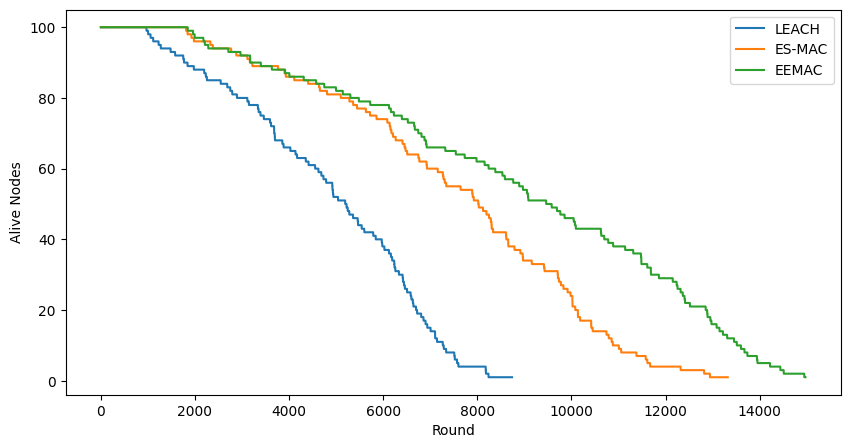

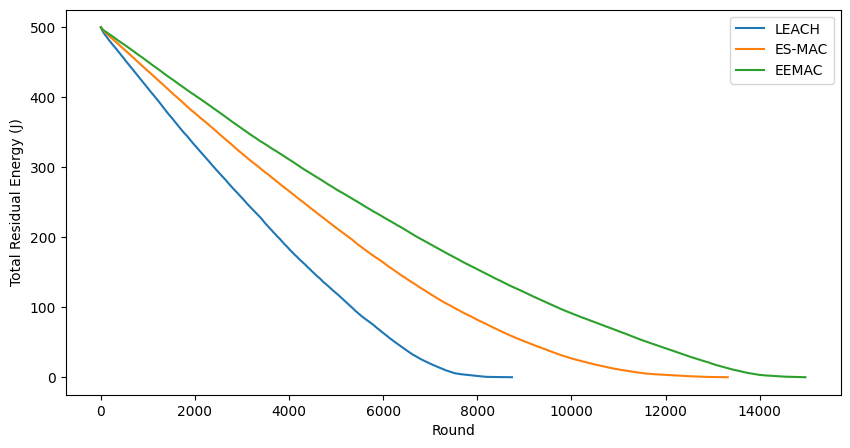

In [ ]:
alive_leach, energy_leach, death_leach = run_protocol("LEACH")
alive_esmac, energy_esmac, death_esmac = run_protocol("ESMAC")
alive_eemac, energy_eemac, death_eemac = run_protocol("EEMAC")

plt.figure(figsize=(10,5))
plt.plot(alive_leach, label="LEACH")
plt.plot(alive_esmac, label="ES-MAC")
plt.plot(alive_eemac, label="EEMAC")
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(energy_leach, label="LEACH")
plt.plot(energy_esmac, label="ES-MAC")
plt.plot(energy_eemac, label="EEMAC")
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.legend()
plt.show()
